# Classify a Roman (RMDC26) light curve with BinML

This notebook needs network access: it fetches one event from the RGES-PIT **RMDC26** release,
an independent simulation of Roman's bulge survey made with GULLS
(`RGES-PIT/MachineLearning` on the Hugging Face Hub, ~172 GB, queried remotely by event id,
pinned to one dataset revision).
Runtime is about a minute after the one-time 150 MB metadata download.

Four things `binml.gulls` handles for you, each of which went wrong at least once before it did:

1. the dataset **revision is pinned** (the tables were re-uploaded on 2026-08-18; mixing releases
   pairs events with the wrong metadata);
2. the model is handed **one contiguous season**, found from the epoch table, not a window
   centred on the peak (the mission observes 685 of 1,717 days in ten seasons);
3. the **baseline is measured from the data** (the catalogue value is ~0.47 mag off in this release);
4. the **gap-aware, finite-source checkpoint** is used, with its own threshold, chosen on our own
   simulated seasons with RMDC26's measured pauses imposed (never on RMDC26 itself): the shipped
   weights were trained on a continuous grid and fail on the schedule's F146 pauses, 43-44 h per
   season in six or seven pauses whose phases differ from season to season (README and
   `paper/REVISION.md`).

In [1]:
import warnings, numpy as np, matplotlib.pyplot as plt
warnings.simplefilter("ignore")
import binml
from binml import gulls

seasons, epoch_map, meta = gulls.load_tables()           # cached under ~/.cache/binml/rmdc26
print(f"revision {gulls.REVISION[:8]}, {len(meta):,} events, {len(seasons)} seasons "
      f"({sum(s.dense for s in seasons)} high-cadence)")
for s in seasons:
    print(f"  season {s.index}: {s.end - s.start:5.1f} d, {s.n_epochs:6d} epochs, {'dense' if s.dense else 'low-cadence'}")

revision a338d5ba, 377,999 events, 10 seasons (6 high-cadence)
  season 0:  70.7 d,  16363 epochs, dense
  season 1:  70.7 d,  16364 epochs, dense
  season 2:  70.7 d,  16370 epochs, dense
  season 3:  65.1 d,    196 epochs, low-cadence
  season 4:  65.1 d,    196 epochs, low-cadence
  season 5:  65.1 d,    196 epochs, low-cadence
  season 6:  65.1 d,    196 epochs, low-cadence
  season 7:  70.7 d,  16360 epochs, dense
  season 8:  70.7 d,  16369 epochs, dense
  season 9:  70.7 d,  16364 epochs, dense


In [2]:
# the recommended gap-aware checkpoint (finite-source single lenses + the measured RMDC26 pauses), shipped as
# binml/weights/binml-gapaware.pt, and its threshold: chosen at 90% purity on our own simulated seasons with the
# measured RMDC26 pauses imposed (validation/gulls/calibrate_gapped_threshold.py), full pool
import json
clf = binml.Classifier(weights="gapaware")
THRESHOLD = binml.GAPAWARE_THRESHOLD
cal = json.load(open("../validation/gulls/gapped_threshold_fspl5s_seasons_g08_seasons.json"))["arms"]["rmdc26_gapped"]["pool"]
assert THRESHOLD == cal["full_pool"]["threshold"]
print(f"threshold {THRESHOLD:.4f} (68% of random validation slices: {cal['slice_thresholds']['p16']:.3f}-{cal['slice_thresholds']['p84']:.3f})")

threshold 0.9563 (68% of random validation slices: 0.947-0.965)


In [3]:
# a planetary event (1S2L) whose peak falls in a high-cadence season
event_id = 306535
res = gulls.classify_event(clf, event_id, seasons, epoch_map, meta)
print({k: v for k, v in res.items() if k != "seasons"})
for s in res["seasons"]:
    print(f"season {s['season']}: {s['n_f146']} F146 epochs, bands {s['bands']} -> {s['label']}  "
          f"P(NonPSPL) = {s['probabilities']['NonPSPL']:.3f}  ({'flag' if s['probabilities']['NonPSPL'] >= THRESHOLD else 'no flag'} at {THRESHOLD:.3f})")

{'sim_label': 'RMDC26_1S2L_ML', 'meaning': 'planetary lens (-> NonPSPL)', 't0_bjd': 2461649.31747114, 'tE_days': 46.44956171615, 'm_base_empirical': 19.62, 'm_base_catalogue': 19.149, 'peak_season': 1, 'peak_in_dense_season': True, 'mode': 'peak', 'p_nonpspl_max': 0.9925, 'event_id': 306535}
season 1: 7701 F146 epochs, bands ['F087', 'F146', 'F213'] -> NonPSPL  P(NonPSPL) = 0.993  (flag at 0.956)


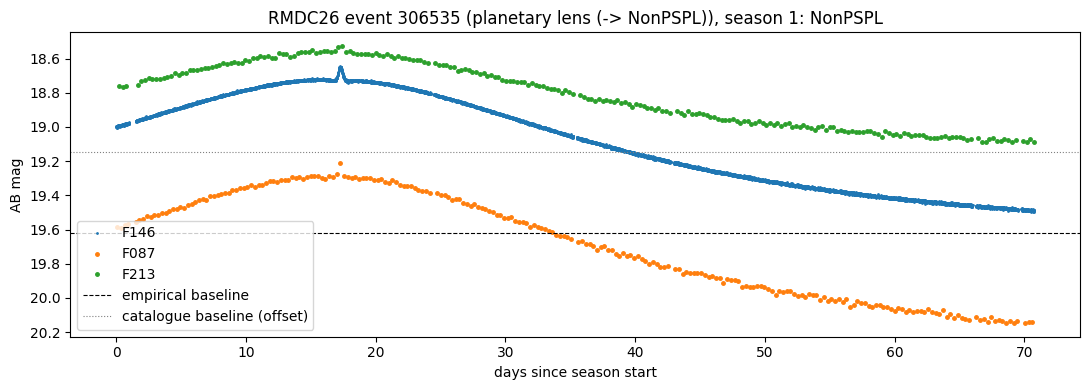

In [4]:
s = res["seasons"][0]
fig, ax = plt.subplots(figsize=(11, 4))
for band, (t, m) in s["_bands"].items():
    ax.plot(t, m, ".", ms=2 if band == "F146" else 5, label=band)
ax.axhline(res["m_base_empirical"], c="k", lw=0.8, ls="--", label="empirical baseline")
ax.axhline(res["m_base_catalogue"], c="grey", lw=0.8, ls=":", label="catalogue baseline (offset)")
ax.invert_yaxis(); ax.set_xlabel("days since season start"); ax.set_ylabel("AB mag"); ax.legend()
ax.set_title(f"RMDC26 event {event_id} ({res['meaning']}), season {s['season']}: {s['label']}")
plt.tight_layout()

## Watching the season unfold

The same half-day protocol as the paper's partial-light-curve evaluation: score growing prefixes
of the season and see when the anomaly probability first crosses the threshold. Note the season's
F146 pauses (the vertical bands of missing points; six or seven per season, at phases that differ
between seasons): the shipped weights read those as evidence against a single lens, which is why
the gap-aware checkpoint exists.

first crossing at day 25.5


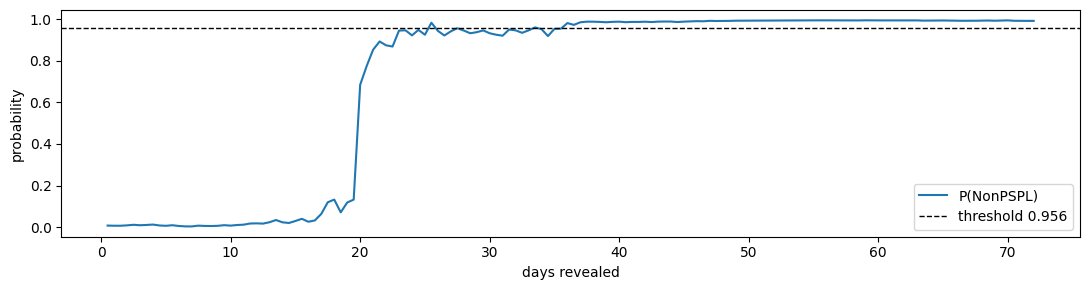

In [5]:
days, probs = clf.predict_evolution(s["_bands"], m_base_ref=res["m_base_empirical"], t_start=0.0, n_steps=144)
i_non = clf.class_names.index("NonPSPL")
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(days, probs[:, i_non], label="P(NonPSPL)"); ax.axhline(THRESHOLD, ls="--", c="k", lw=1, label=f"threshold {THRESHOLD:.3f}")
ax.set_xlabel("days revealed"); ax.set_ylabel("probability"); ax.legend(); plt.tight_layout()
cross = days[np.flatnonzero(probs[:, i_non] >= THRESHOLD)]
print("first crossing at day", cross[0] if cross.size else "never")

## A single lens, and an event whose peak falls between seasons

Of RMDC26's eligible events, about a quarter of the single lenses but only a tenth of the planetary events peak in
one of the ~115-day gaps between seasons, where nothing is observed (paper §8.4). `mode="adjacent"` scores the high-cadence season on each side of the gap and
reports the maximum anomaly probability: the per-season combiner measured in `paper/REVISION.md`
§1½ (row 9); seasons that hold only a wing of the event need their own operating point. Event 315360 is a planetary lens (t_E 9 d) whose peak falls about two days before a
season starts; 3022 is a single lens whose peak is inside a season, scored with the default
`mode="peak"`.

In [6]:
for eid, mode in ((3022, "peak"), (315360, "adjacent")):
    r = gulls.classify_event(clf, eid, seasons, epoch_map, meta, mode=mode)
    scored = [x for x in r["seasons"] if "probabilities" in x]
    print(f"{eid}: {r['meaning']:45s} peak season {r['peak_season']} (dense: {r['peak_in_dense_season']}); mode={mode}: "
          f"seasons {[x['season'] for x in scored]}, max P(NonPSPL) = {r['p_nonpspl_max']}")

3022: single lens (-> PSPL)                         peak season 1 (dense: True); mode=peak: seasons [1], max P(NonPSPL) = 0.0869


315360: planetary lens (-> NonPSPL)                   peak season None (dense: False); mode=adjacent: seasons [1, 2], max P(NonPSPL) = 0.9988


## What the numbers on the whole population look like

Read from the committed artifacts, so they cannot drift from the tables. Every table is regenerated by
`validation/gulls/gulls_summary_tables.py` (from a clone: `--scores validation/gulls/rmdc26_scores.csv.gz`);
the full account, including the experiments that did not work, is in `paper/REVISION.md` §1½.
Recall against RMDC26's generator labels is not bounded by the share of events with a claimable anomaly:
the checkpoint also flags some planetary events whose anomaly our label policy would not claim.

In [7]:
T = json.load(open("../validation/gulls/transfer_tradeoff_all.json"))
m, s = T["models"]["fspl5s_seasons_g08"], T["models"]["shipped"]
fa = lambda x: x["frozen_threshold"]["fa_1S1L_k_n"][0] / x["frozen_threshold"]["fa_1S1L_k_n"][1]
at = lambda x, t: next(a for a in x["recall_at_matched_fa"] if abs(a["fa_target"] - t) < 1e-9)
g = json.load(open("../validation/gulls/gapped_threshold_fspl5s_seasons_g08_seasons.json"))["arms"]["rmdc26_gapped"]["gulls_at_full_pool_threshold"]
D = json.load(open("../validation/gulls/transfer_detectability_relabel.json"))
rl, fz = D["relabelling"], D["models"]["fspl5s_seasons_g08"]["at_threshold"]["frozen"]
r = lambda d: d["k"] / d["n"]
print(f"{T['n_matched_dense']:,} matched in-season events")
print(f"single lenses flagged: {100 * fa(m):.1f}% at the shipped threshold {T['frozen_threshold']:.3f}, "
      f"{100 * g['fa_1S1L']:.1f}% at the recalibrated {THRESHOLD:.3f} (shipped weights: {100 * fa(s):.1f}%)")
wat = lambda x, t: next(a for a in x["weighted"]["recall_at_matched_fa"] if abs(a["fa_target"] - t) < 1e-9)
print(f"planetary (1S2L) recall at a 5.2% single-lens false-alarm budget: {at(m, 0.052)['recall_1S2L']:.2f} per event, "
      f"{wat(m, 0.052)['recall_1S2L']:.2f} weighted by event rate (shipped weights {at(s, 0.052)['recall_1S2L']:.2f} / {wat(s, 0.052)['recall_1S2L']:.2f})")
print(f"planetary events with no anomaly our label policy would claim within the season: "
      f"1S2L {100 * (1 - rl['RMDC26_1S2L_ML']['frac_NonPSPL']):.0f}%, 2S2L {100 * (1 - rl['RMDC26_2S2L_ML']['frac_NonPSPL']):.0f}%")
print(f"recall on claimable anomalies at {T['frozen_threshold']:.3f}: 1S2L {r(fz['recall_1S2L_detectable']):.2f}, "
      f"2S2L {r(fz['recall_2S2L_detectable']):.2f}; binaries flagged WITHOUT a claimable anomaly: {100 * r(fz['flag_binaries_undetectable']):.0f}%")


56,975 matched in-season events
single lenses flagged: 6.3% at the shipped threshold 0.904, 2.4% at the recalibrated 0.956 (shipped weights: 35.6%)
planetary (1S2L) recall at a 5.2% single-lens false-alarm budget: 0.39 per event, 0.41 weighted by event rate (shipped weights 0.21 / 0.14)
planetary events with no anomaly our label policy would claim within the season: 1S2L 44%, 2S2L 46%
recall on claimable anomalies at 0.904: 1S2L 0.54, 2S2L 0.62; binaries flagged WITHOUT a claimable anomaly: 25%
